In [2]:
#Importing The Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
#Loaded the dataset
df = pd.read_csv("train_aWnotuB.csv")

In [4]:
#Basic EDA

In [5]:
#df.head used to display top 5 rows of the dataset
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [6]:
#df.tail is used to print last 5 rows of dataset
df.tail()

,DateTime,Junction,Vehicles,ID
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224
48119,2017-06-30 23:00:00,4,12,20170630234


In [7]:
# responsible for printing of shape of dataset, inshort shows rows and columns of dataset(48120 are rows & 6 are columns)
df.shape

(48120, 4)

In [8]:
# used to display no of columns that are available in dataset
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

In [9]:
#showws basic datail of dataset like: data type,null value,columns etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [10]:
# this is basically used to find no of null values in columns( as you see 0 null values in all columns)
df.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [11]:
#used to display if the rows are duplicates or not
df.duplicated().sum()

np.int64(0)

In [12]:
#shows Statistical summary eg mean,median etc
df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [13]:
# As, DateTime column with 48120 non-null values and whose dtype is object, we need to convert to DateTime format
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [14]:
df.info() #As dtype has changed of DateTime column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB


In [15]:
#Extracting
df["Year"]=df["DateTime"].dt.year #The line df["year"] = df["DateTime"].dt.year extracts the year component from a datetime column in a pandas DataFrame and stores it in a new column called "year".
df["Month"]=df["DateTime"].dt.month
df["Day"]=df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.day_name()

In [16]:
df.head()# We Can See that we have seperated Year,Month,Day,Hour...

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,Sunday
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,Sunday
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,Sunday
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,Sunday
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,Sunday


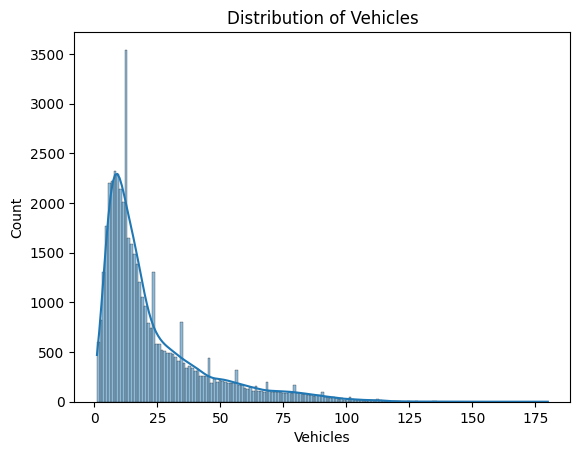

In [17]:
sns.histplot(df["Vehicles"], kde=True)
plt.title("Distribution of Vehicles")
plt.show()

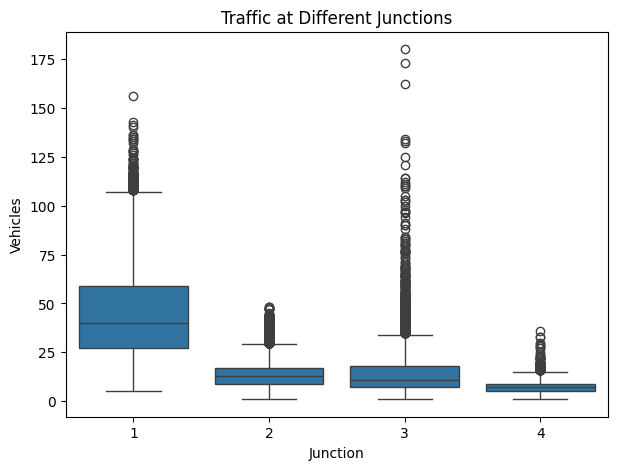

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Junction", y="Vehicles", data=df)
plt.title("Traffic at Different Junctions")
plt.show()

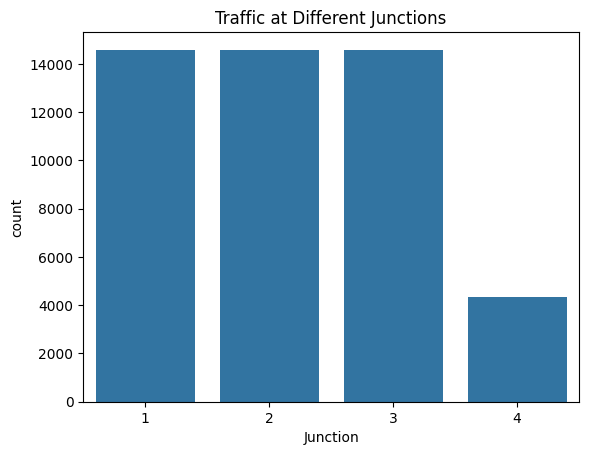

In [19]:
sns.countplot(x="Junction", data=df)
plt.title("Traffic at Different Junctions")
plt.show()

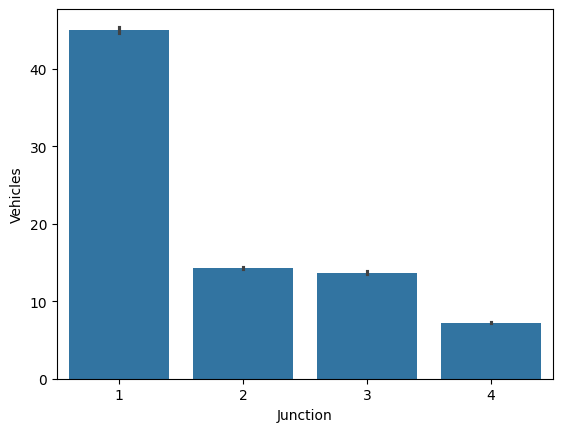

In [20]:
sns.barplot(
    x="Junction",
    y="Vehicles",
    data=df
)

plt.show()

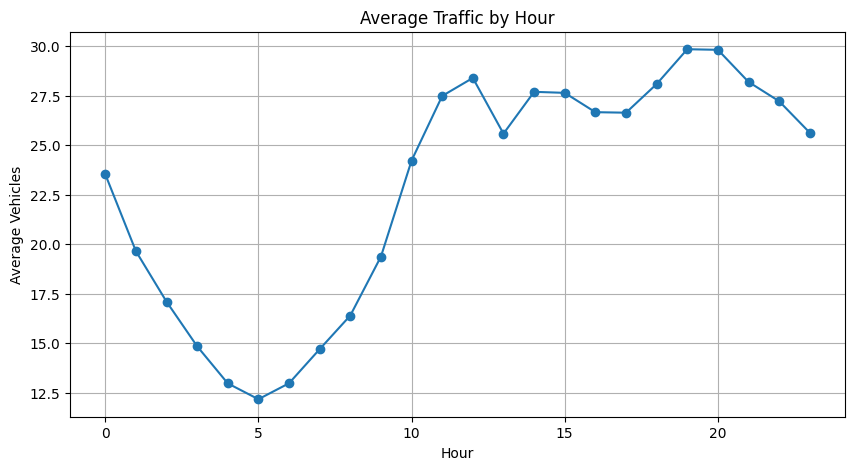

In [21]:
hourly = df.groupby("Hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))
hourly.plot(marker="o")
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.grid(True)
plt.show()

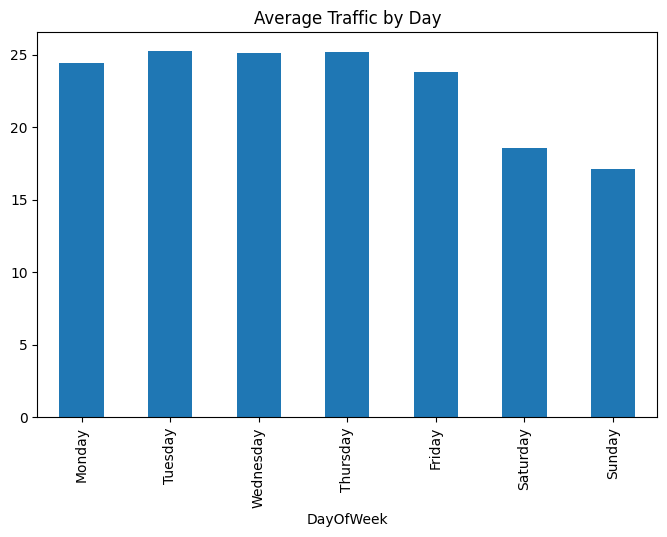

In [22]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

daily = df.groupby("DayOfWeek")["Vehicles"].mean().reindex(day_order)

plt.figure(figsize=(8,5))
daily.plot(kind="bar")
plt.title("Average Traffic by Day")
plt.show()

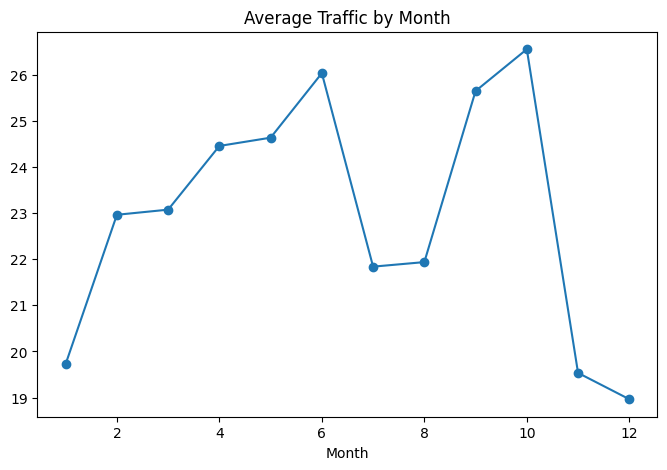

In [23]:
monthly = df.groupby("Month")["Vehicles"].mean()

plt.figure(figsize=(8,5))
monthly.plot(marker="o")
plt.title("Average Traffic by Month")
plt.show()

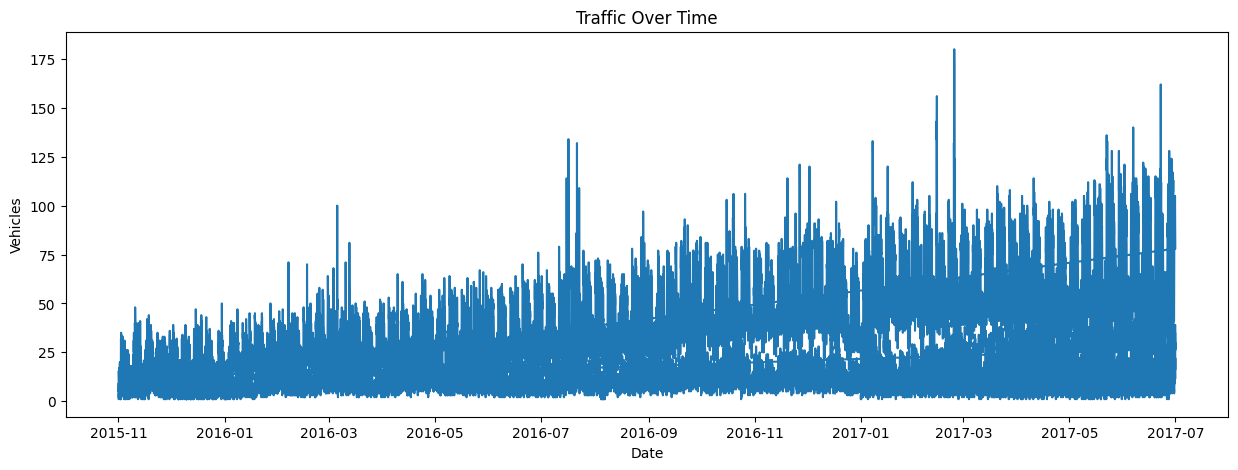

In [24]:
plt.figure(figsize=(15,5))
plt.plot(df["DateTime"], df["Vehicles"])
plt.title("Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Vehicles")
plt.show()

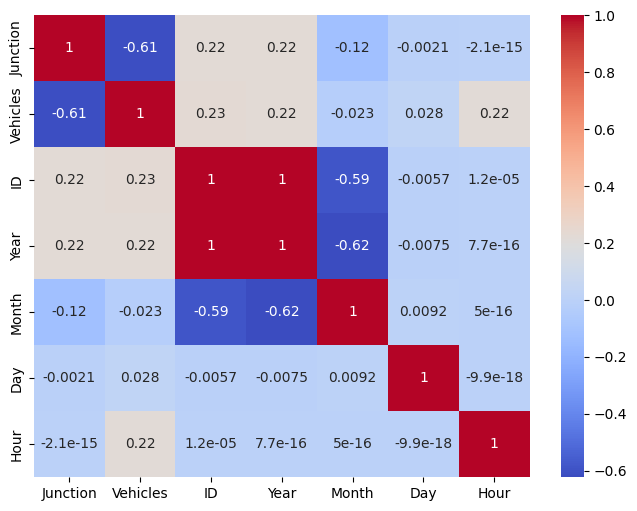

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

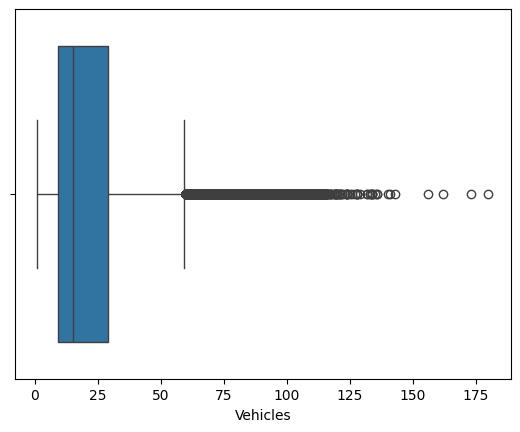

In [26]:
sns.boxplot(
    x=df["Vehicles"]
)

plt.show()

In [27]:
df.head(3)

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,Sunday
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,Sunday
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,Sunday


In [28]:
df = pd.get_dummies(
    df,
    columns=['DayOfWeek'],
    drop_first=True
)

In [29]:
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,False,False,True,False,False,False
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,False,False,True,False,False,False
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,False,False,True,False,False,False
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,False,False,True,False,False,False
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,False,False,True,False,False,False


In [30]:
df.head(2)

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,False,False,True,False,False,False
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,False,False,True,False,False,False


In [31]:
#Split
X = df.drop(columns=["ID", "Vehicles", "DateTime"])
y = df["Vehicles"]

In [32]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
#Now We Will Train the Model By Linear Regression
from sklearn.linear_model import LinearRegression

Lr=LinearRegression()
Lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
#We Will Make Prediction
y_pred=Lr.predict(X_test)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mae :", mae)
print("RMSE:", rmse)
print("R2  :", r2)# Explains about 60.5% of the variation in traffic. 


Mae : 9.580567819335867
RMSE: 12.685031909236708
R2  : 0.6051740397115672


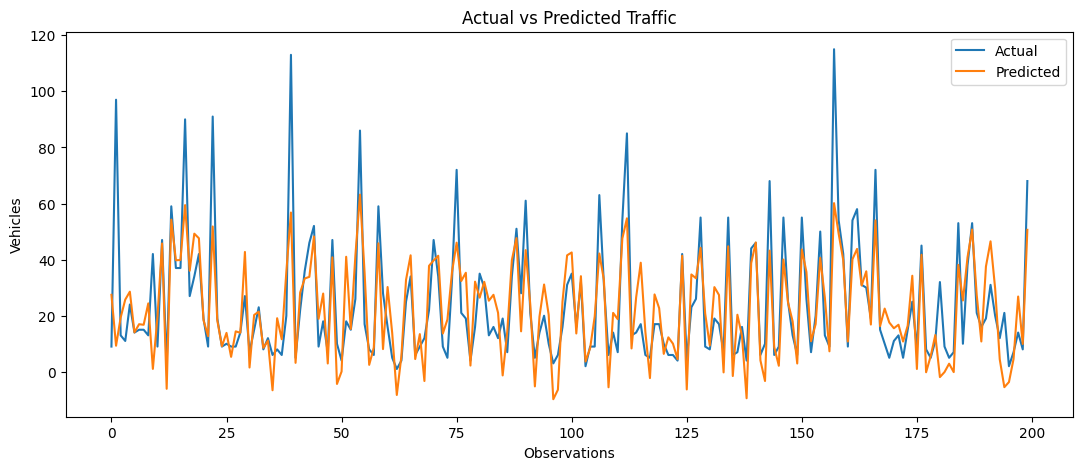

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.xlabel("Observations")
plt.ylabel("Vehicles")
plt.title("Actual vs Predicted Traffic")
plt.legend()
plt.show()

In [37]:
#Random Forest 

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
#Model Creation
rf = RandomForestRegressor(
    n_estimators=100, #makes 100 DT, More DT more acc but training time will increase too
    random_state=42,
    n_jobs=-1 #uses cpu core eg 1 for slow,-1 for fast or can say uses all core
)

In [40]:
#Training The Model
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred_rf=rf.predict(X_test) #We created new var for random forest which is y_pred_rf so that it couldnt mix with prev models

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2 = r2_score(y_test, y_pred_rf)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)#Explains 96.8% of the variation.

#worse model performance compared to your linear regression attempt.

MAE : 2.4329156275976724
RMSE: 3.6091363727960926
R2  : 0.9680383525297601


In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                Feature  Importance
0              Junction    0.516432
1                  Year    0.166581
4                  Hour    0.145682
2                 Month    0.067571
3                   Day    0.032338
6    DayOfWeek_Saturday    0.030823
7      DayOfWeek_Sunday    0.029712
5      DayOfWeek_Monday    0.004054
8    DayOfWeek_Thursday    0.002799
9     DayOfWeek_Tuesday    0.002070
10  DayOfWeek_Wednesday    0.001938


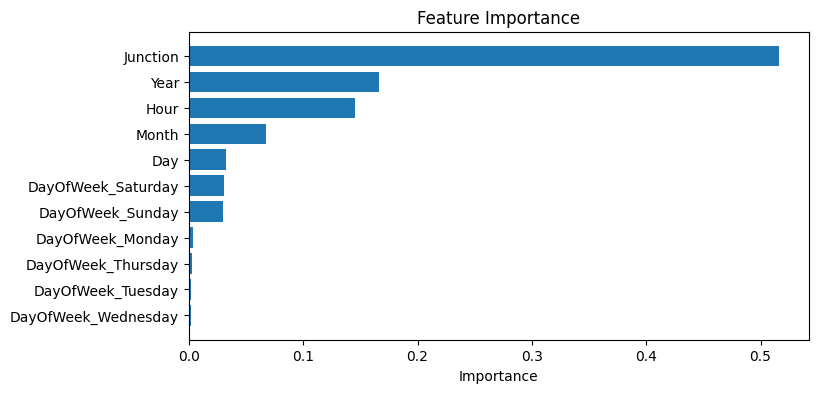

In [44]:
plt.figure(figsize=(8,4))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

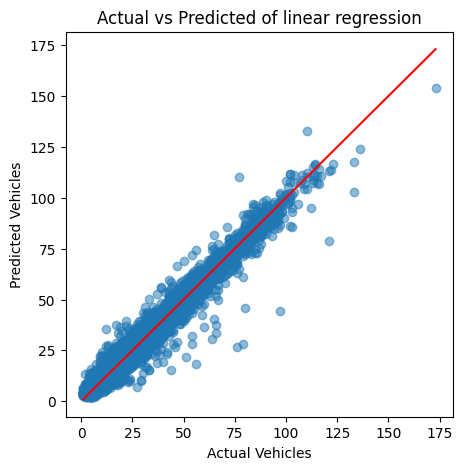

In [45]:
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Actual vs Predicted of linear regression")

plt.show()# points lie close to the red line, model is making accurate predictions.

In [46]:
#Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV

In [47]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],# how much branches of DT, more depth more acc but training time will increase too
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [48]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20, #search will try 20 random combinations of the hyperparameters listed below.
    cv=5,#split data into 5 parts and train 4 parts and test on 1 part, repeat this 5 times for each combination of hyperparameters then avg
    scoring="r2",#look for max r2 score
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
print(random_search.best_params_)
print(random_search.best_score_)
#best parameter are listed below

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
0.9589897464156303


In [50]:
best_rf = random_search.best_estimator_

In [51]:
best_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred_best = best_rf.predict(X_test)

In [53]:
print("MAE :", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", mean_squared_error(y_test, y_pred_best) ** 0.5)
print("R²  :", r2_score(y_test, y_pred_best))

MAE : 2.433181733167082
RMSE: 3.7358800802102246
R²  : 0.9657541124269613


In [54]:
print("Train R²:", best_rf.score(X_train, y_train))
print("Test R² :", best_rf.score(X_test, y_test))

Train R²: 0.9947103829279523
Test R² : 0.9657541124269613


In [55]:
#Compared to Linear Regression model Random Forest with hypertune was pretty good

In [56]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
0              Junction    0.592518
4                  Hour    0.135767
1                  Year    0.124054
2                 Month    0.058065
3                   Day    0.038355
7      DayOfWeek_Sunday    0.020224
6    DayOfWeek_Saturday    0.018041
5      DayOfWeek_Monday    0.004125
9     DayOfWeek_Tuesday    0.003144
8    DayOfWeek_Thursday    0.002924
10  DayOfWeek_Wednesday    0.002782


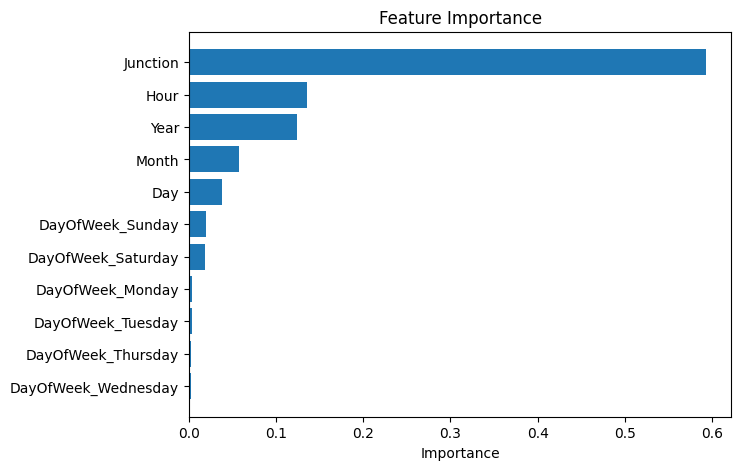

In [57]:
plt.figure(figsize=(7,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

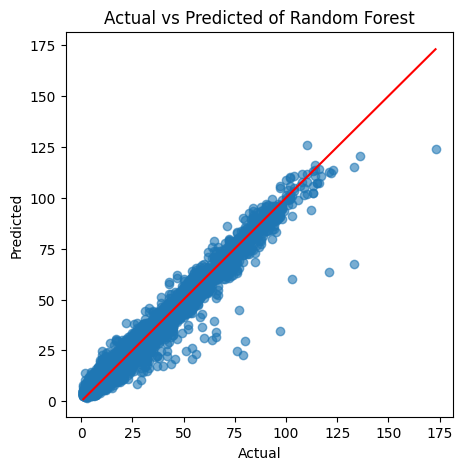

In [58]:
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred_best, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted of Random Forest")

plt.show()

In [59]:
#XGboost

In [60]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y_test, y_pred_xgb)**0.5)
print("R²  :", r2_score(y_test, y_pred_xgb))

MAE : 2.725289821624756
RMSE: 4.540618682247842
R²  : 0.9494113922119141


In [62]:
import joblib


In [63]:
joblib.dump(best_rf, "traffic_prediction_model.pkl")
model = joblib.load("traffic_prediction_model.pkl")

In [64]:
#11. Predict on Unseen Test Data   

In [65]:
test = pd.read_csv("datasets_8494_11879_test_BdBKkAj.csv")

In [66]:
test.head()

,DateTime,Junction,ID
0,2017-07-01 00:00:00,1,20170701001
1,2017-07-01 01:00:00,1,20170701011
2,2017-07-01 02:00:00,1,20170701021
3,2017-07-01 03:00:00,1,20170701031
4,2017-07-01 04:00:00,1,20170701041


In [67]:
test["DateTime"] = pd.to_datetime(test["DateTime"])

In [68]:
test["Year"] = test["DateTime"].dt.year
test["Month"] = test["DateTime"].dt.month
test["Day"] = test["DateTime"].dt.day
test["Hour"] = test["DateTime"].dt.hour
test["DayOfWeek"] = test["DateTime"].dt.day_name()
 

In [69]:
test = pd.get_dummies(
    test,
    columns=["DayOfWeek"],
    drop_first=True
)

In [70]:
test_features = test.drop(
    columns=["ID", "DateTime"]
)

In [71]:
import joblib
model = joblib.load("traffic_prediction_model.pkl")


In [72]:
predictions = model.predict(test_features)

In [73]:
predictions[:10]

array([61.34 , 57.72 , 43.87 , 38.21 , 33.665, 32.12 , 32.3  , 35.82 ,
       41.97 , 45.665])

In [74]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "Vehicles": predictions
})

submission.head()

,ID,Vehicles
0,20170701001,61.340
1,20170701011,57.720
2,20170701021,43.870
3,20170701031,38.210
4,20170701041,33.665


In [75]:
submission.to_csv(
    "traffic_predictions.csv",
    index=False
)

In [80]:
import joblib
model = joblib.load("traffic_prediction_model.pkl")

In [83]:
import os

print(os.getcwd())
print(os.listdir())

k:\data\Cd\ML\UpSkill\Smart City Traffic Patterns Forecasting
['app.py', 'datasets_8494_11879_test_BdBKkAj.csv', 'Notebook.ipynb', 'traffic_predictions.csv', 'traffic_prediction_model.pkl', 'train_aWnotuB.csv']


In [ ]:
"""
- The objective was to predict hourly traffic volume at different city junctions.
- After preprocessing and feature engineering, multiple models were evaluated.
- Linear Regression was used as a baseline model.
- Random Forest Regressor achieved the best performance.
 -XGBoost Was also Used but didnt perform well as Random Forest
 
- Final Model Performance:
    - MAE: 2.43
    - RMSE: 3.74
    - R² Score: 0.966
- The trained model was saved and successfully used to predict traffic on unseen test data.
"""